In [1]:
import pandas as pd

# -----------------------------
# Paths: OLD 48-person cohort
# -----------------------------
paths_old = {
    "Microglia": "/n/scratch/users/a/adm808/Contrasts/NPvsCAD/Mathys_Old_Data_DEG_results/poisson_DE_results_Mic.csv",
    "Oligodendrocytes": "/n/scratch/users/a/adm808/Contrasts/NPvsCAD/Mathys_Old_Data_DEG_results/poisson_DE_results_Oli.csv",
}

# -----------------------------
# Parameters
# -----------------------------
FDR_THRESH = 0.05
TOP_N = 10

# -----------------------------
# Load + inspect
# -----------------------------
dfs_old = {}
for ct, path in paths_old.items():
    df = pd.read_csv(path)
    print(f"\n{ct} (OLD cohort)")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    dfs_old[ct] = df

# -----------------------------
# Print top up/down genes
# -----------------------------
for ct, df in dfs_old.items():
    print("\n" + "="*80)
    print(f"{ct.upper()} — OLD 48-person cohort")
    print("="*80)

    df_sig = df[df["p_adj"] < FDR_THRESH].copy()

    if df_sig.empty:
        print("No genes pass FDR threshold.")
        continue

    # Upregulated (AD > non-AD)
    up = df_sig.sort_values("log2FC", ascending=False).head(TOP_N)
    print("\nTop UPREGULATED genes (AD > non-AD):")
    print(up[["gene", "log2FC", "p_adj"]].to_string(index=False))

    # Downregulated (AD < non-AD)
    down = df_sig.sort_values("log2FC", ascending=True).head(TOP_N)
    print("\nTop DOWNREGULATED genes (AD < non-AD):")
    print(down[["gene", "log2FC", "p_adj"]].to_string(index=False))


Microglia (OLD cohort)
Shape: (8851, 8)
Columns: ['gene', 'estimate_AD', 'se_AD', 'pval_AD', 'n_cells', 'p_adj', 'log2FC', 'DEG']

Oligodendrocytes (OLD cohort)
Shape: (13838, 8)
Columns: ['gene', 'estimate_AD', 'se_AD', 'pval_AD', 'n_cells', 'p_adj', 'log2FC', 'DEG']

MICROGLIA — OLD 48-person cohort

Top UPREGULATED genes (AD > non-AD):
    gene       log2FC        p_adj
   ACOXL 10071.471245 4.906398e-75
    UBL7  8433.647835 9.438038e-57
     CAT  6718.373261 3.898891e-76
  CAB39L  3131.899979 4.718927e-41
  TUBA1B     1.597078 1.533594e-02
  SLC4A7     1.107794 4.294379e-02
RASGEF1B     0.987160 2.724399e-02
    SPP1     0.985035 1.616913e-02
    PSAP     0.938349 2.724399e-02
    APOE     0.745815 4.827601e-02

Top DOWNREGULATED genes (AD < non-AD):
     gene       log2FC         p_adj
    ETAA1 -4730.778622  1.662533e-06
 C1orf101 -4597.992720 2.864568e-100
   ACTL6A -3448.710911  0.000000e+00
     PRF1    -3.788811  1.702731e-02
HIST1H2BG    -3.374502  6.144757e-04
   FBXO25  


=== Microglia ===


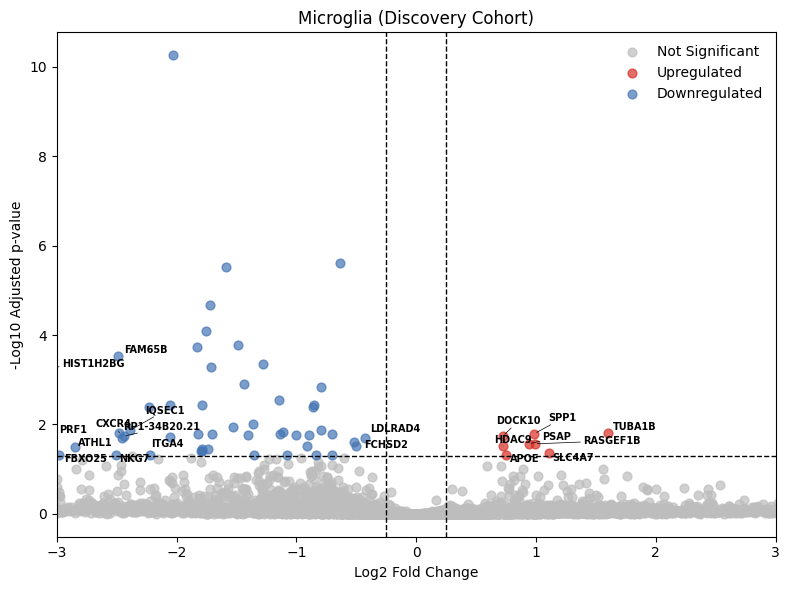

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure7/volcano_Microglia_OLD48.png

=== Oligodendrocytes ===


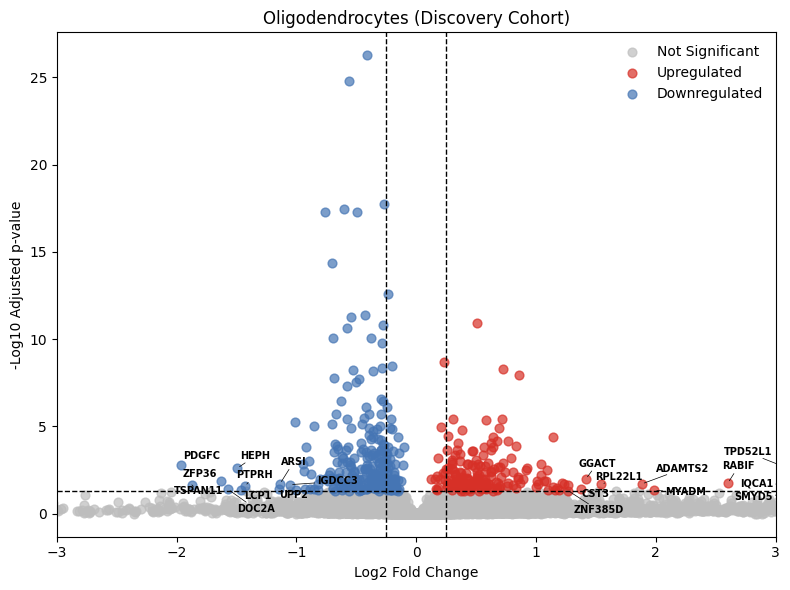

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure7/volcano_Oligodendrocytes_OLD48.png

All OLD 48-person volcano plots generated.


In [5]:
# ============================================================
# Volcano plots — OLD 48-person Mathys cohorts
# One volcano per cell type
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

# -----------------------------
# Paths
# -----------------------------
paths_old = {
    "Microglia": "/n/scratch/users/a/adm808/Contrasts/NPvsCAD/Mathys_Old_Data_DEG_results/poisson_DE_results_Mic.csv",
    "Oligodendrocytes": "/n/scratch/users/a/adm808/Contrasts/NPvsCAD/Mathys_Old_Data_DEG_results/poisson_DE_results_Oli.csv",
}

fig_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure7/"
os.makedirs(fig_dir, exist_ok=True)

# -----------------------------
# Parameters
# -----------------------------
FDR_THRESH = 0.05
LOGFC_THRESH = 0.25
TOP_N = 10

# -----------------------------
# Loop per cell type
# -----------------------------
for ct, path in paths_old.items():
    print(f"\n=== {ct} ===")

    df = pd.read_csv(path)
    df = df[df["p_adj"].notnull() & df["log2FC"].notnull()].copy()

    # Remove NLGN4Y only for Oligodendrocytes becuase it destroys scale
    if ct == "Oligodendrocytes":
        df = df[df["gene"] != "NLGN4Y"].copy()

    # Avoid -inf
    df.loc[df["p_adj"] == 0, "p_adj"] = 1e-308
    df["-log10_padj"] = -np.log10(df["p_adj"])

    # Cap extreme FCs
    df = df[df["log2FC"].abs() <= 20]

    # Assign groups
    df["group"] = "Not Significant"
    df.loc[(df["p_adj"] < FDR_THRESH) & (df["log2FC"] > 0), "group"] = "Upregulated"
    df.loc[(df["p_adj"] < FDR_THRESH) & (df["log2FC"] < 0), "group"] = "Downregulated"

    # Color map
    color_map = {
        "Not Significant": "#bdbdbd",
        "Upregulated": "#d73027",   # red
        "Downregulated": "#4575b4", # blue
    }

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(8, 6))

    for group, color in color_map.items():
        subset = df[df["group"] == group]
        plt.scatter(
            subset["log2FC"],
            subset["-log10_padj"],
            color=color,
            s=40,
            alpha=0.7,
            label=group
        )

    plt.axvline(x=LOGFC_THRESH, color="black", linestyle="--", lw=1)
    plt.axvline(x=-LOGFC_THRESH, color="black", linestyle="--", lw=1)
    plt.axhline(y=-np.log10(FDR_THRESH), color="black", linestyle="--", lw=1)

    plt.xlim(-3, 3)
    plt.xlabel("Log2 Fold Change")
    plt.ylabel("-Log10 Adjusted p-value")
    plt.title(f"{ct} (Discovery Cohort)")
    plt.legend(frameon=False)

    # -----------------------------
    # Label top genes
    # -----------------------------
    sig_df = df[df["p_adj"] < FDR_THRESH].copy()

    top_up = sig_df.sort_values("log2FC", ascending=False).head(TOP_N)
    top_down = sig_df.sort_values("log2FC", ascending=True).head(TOP_N)
    label_df = pd.concat([top_up, top_down]).drop_duplicates(subset="gene")

    texts = []
    for _, row in label_df.iterrows():
        texts.append(
            plt.text(
                row["log2FC"],
                row["-log10_padj"],
                row["gene"],
                fontsize=7,
                fontweight="bold"
            )
        )

    adjust_text(texts, arrowprops=dict(arrowstyle="-", lw=0.5, color="black"))

    plt.tight_layout()
    out_path = os.path.join(fig_dir, f"volcano_{ct.replace(' ', '_')}_OLD48.png")
    plt.savefig(out_path, dpi=300)
    plt.show()

    print(f"Saved: {out_path}")

print("\nAll OLD 48-person volcano plots generated.")


=== Microglia ===


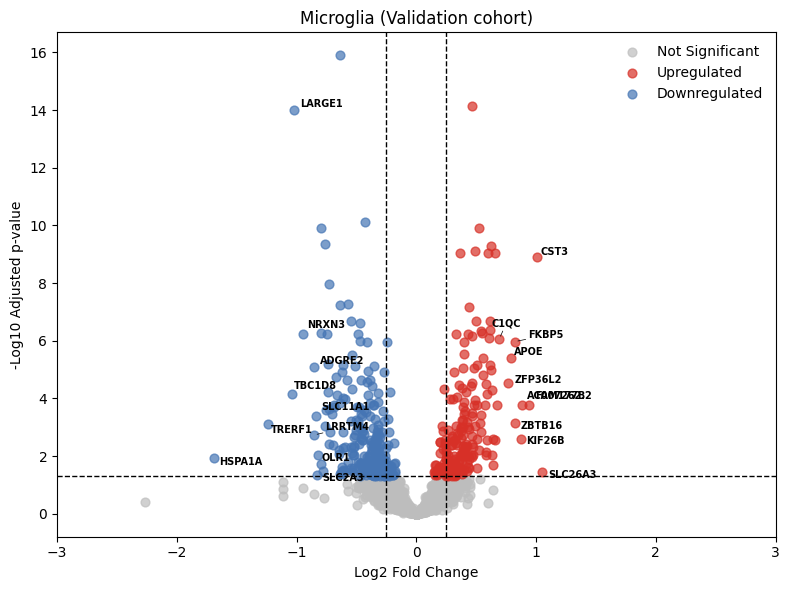

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure7/volcano_Microglia_NEW48.png

=== Oligodendrocytes ===


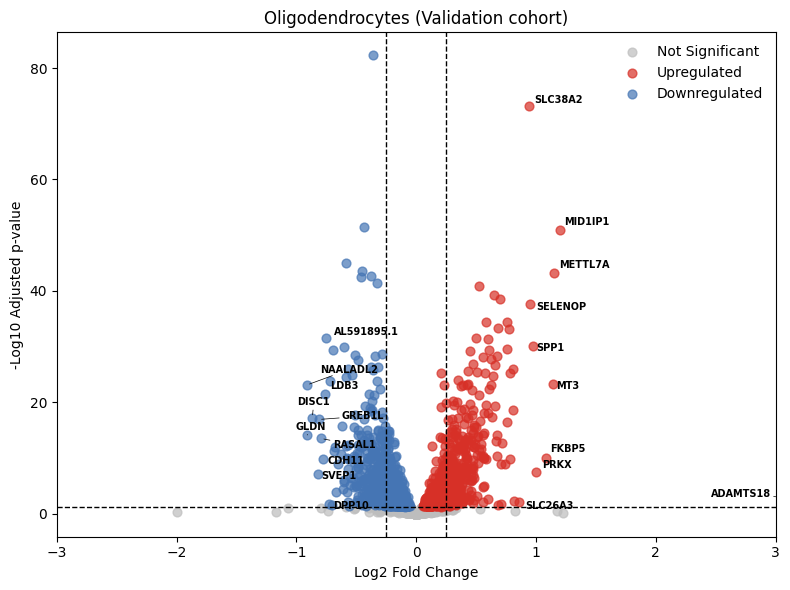

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure7/volcano_Oligodendrocytes_NEW48.png

All NEW 48-person volcano plots generated.


In [3]:
# ============================================================
# Volcano plots — NEW 48-person Mathys cohorts
# One volcano per cell type
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

# -----------------------------
# Paths
# -----------------------------
paths_new = {
    "Microglia": "/n/scratch/users/a/adm808/Contrasts/NPvsCAD/Mathys_New_Data_DEG_results/poisson_DE_results_PFC_Mic.csv",
    "Oligodendrocytes": "/n/scratch/users/a/adm808/Contrasts/NPvsCAD/Mathys_New_Data_DEG_results/poisson_DE_results_PFC_Oli.csv",
}

fig_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure7/"
os.makedirs(fig_dir, exist_ok=True)

# -----------------------------
# Parameters
# -----------------------------
FDR_THRESH = 0.05
LOGFC_THRESH = 0.25
TOP_N = 10

# -----------------------------
# Loop per cell type
# -----------------------------
for ct, path in paths_new.items():
    print(f"\n=== {ct} ===")

    df = pd.read_csv(path)
    df = df[df["p_adj"].notnull() & df["log2FC"].notnull()].copy()

    # Avoid -inf
    df.loc[df["p_adj"] == 0, "p_adj"] = 1e-308
    df["-log10_padj"] = -np.log10(df["p_adj"])

    # Cap extreme FCs
    df = df[df["log2FC"].abs() <= 20]

    # Assign groups
    df["group"] = "Not Significant"
    df.loc[(df["p_adj"] < FDR_THRESH) & (df["log2FC"] > 0), "group"] = "Upregulated"
    df.loc[(df["p_adj"] < FDR_THRESH) & (df["log2FC"] < 0), "group"] = "Downregulated"

    # Color map
    color_map = {
        "Not Significant": "#bdbdbd",
        "Upregulated": "#d73027",   # red
        "Downregulated": "#4575b4", # blue
    }

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(8, 6))

    for group, color in color_map.items():
        subset = df[df["group"] == group]
        plt.scatter(
            subset["log2FC"],
            subset["-log10_padj"],
            color=color,
            s=40,
            alpha=0.7,
            label=group
        )

    plt.axvline(x=LOGFC_THRESH, color="black", linestyle="--", lw=1)
    plt.axvline(x=-LOGFC_THRESH, color="black", linestyle="--", lw=1)
    plt.axhline(y=-np.log10(FDR_THRESH), color="black", linestyle="--", lw=1)

    plt.xlim(-3, 3)
    plt.xlabel("Log2 Fold Change")
    plt.ylabel("-Log10 Adjusted p-value")
    plt.title(f"{ct} (Validation cohort)")
    plt.legend(frameon=False)

    # -----------------------------
    # Label top genes
    # -----------------------------
    sig_df = df[df["p_adj"] < FDR_THRESH].copy()

    top_up = sig_df.sort_values("log2FC", ascending=False).head(TOP_N)
    top_down = sig_df.sort_values("log2FC", ascending=True).head(TOP_N)
    label_df = pd.concat([top_up, top_down]).drop_duplicates(subset="gene")

    texts = []
    for _, row in label_df.iterrows():
        texts.append(
            plt.text(
                row["log2FC"],
                row["-log10_padj"],
                row["gene"],
                fontsize=7,
                fontweight="bold"
            )
        )

    adjust_text(texts, arrowprops=dict(arrowstyle="-", lw=0.5, color="black"))

    plt.tight_layout()
    out_path = os.path.join(fig_dir, f"volcano_{ct.replace(' ', '_')}_NEW48.png")
    plt.savefig(out_path, dpi=300)
    plt.show()

    print(f"Saved: {out_path}")

print("\nAll NEW 48-person volcano plots generated.")

In [2]:
import pandas as pd

# -----------------------------
# Paths: NEW 48-person cohort
# -----------------------------
paths_new = {
    "Microglia": "/n/scratch/users/a/adm808/Contrasts/NPvsCAD/Mathys_New_Data_DEG_results/poisson_DE_results_PFC_Mic.csv",
    "Oligodendrocytes": "/n/scratch/users/a/adm808/Contrasts/NPvsCAD/Mathys_New_Data_DEG_results/poisson_DE_results_PFC_Oli.csv",
}

# -----------------------------
# Parameters
# -----------------------------
FDR_THRESH = 0.05
TOP_N = 10

# -----------------------------
# Load + inspect
# -----------------------------
dfs_new = {}
for ct, path in paths_new.items():
    df = pd.read_csv(path)
    print(f"\n{ct} (NEW cohort)")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    dfs_new[ct] = df

# -----------------------------
# Print top up/down genes
# -----------------------------
for ct, df in dfs_new.items():
    print("\n" + "="*80)
    print(f"{ct.upper()} — NEW 48-person cohort")
    print("="*80)

    df_sig = df[df["p_adj"] < FDR_THRESH].copy()

    if df_sig.empty:
        print("No genes pass FDR threshold.")
        continue

    # Upregulated
    up = df_sig.sort_values("log2FC", ascending=False).head(TOP_N)
    print("\nTop UPREGULATED genes (AD > non-AD):")
    print(up[["gene", "log2FC", "p_adj"]].to_string(index=False))

    # Downregulated
    down = df_sig.sort_values("log2FC", ascending=True).head(TOP_N)
    print("\nTop DOWNREGULATED genes (AD < non-AD):")
    print(down[["gene", "log2FC", "p_adj"]].to_string(index=False))


Microglia (NEW cohort)
Shape: (2413, 8)
Columns: ['gene', 'estimate_AD', 'se_AD', 'pval_AD', 'n_cells', 'p_adj', 'log2FC', 'DEG']

Oligodendrocytes (NEW cohort)
Shape: (3022, 8)
Columns: ['gene', 'estimate_AD', 'se_AD', 'pval_AD', 'n_cells', 'p_adj', 'log2FC', 'DEG']

MICROGLIA — NEW 48-person cohort

Top UPREGULATED genes (AD > non-AD):
      gene   log2FC        p_adj
   SLC26A3 1.051021 3.438543e-02
      CST3 1.007607 1.241617e-09
   FAM177B 0.941514 1.676822e-04
AC007262.2 0.879078 1.676822e-04
    KIF26B 0.877666 2.467851e-03
    ZBTB16 0.827199 7.096164e-04
     FKBP5 0.825338 1.068855e-06
      APOE 0.790005 3.989079e-06
   ZFP36L2 0.768061 2.846744e-05
      C1QC 0.693654 8.533581e-07

Top DOWNREGULATED genes (AD < non-AD):
   gene    log2FC        p_adj
 HSPA1A -1.689981 1.164980e-02
 TRERF1 -1.235516 7.605849e-04
 TBC1D8 -1.038578 7.200008e-05
 LARGE1 -1.018416 9.716318e-15
  NRXN3 -0.948707 5.638510e-07
 ADGRE2 -0.855620 8.379838e-06
 LRRTM4 -0.850753 1.838229e-03
SLC11A1 

In [3]:
import pandas as pd
import numpy as np

# -----------------------------
# Parameters (strict)
# -----------------------------
FDR_THRESH = 0.05
MIN_LOG2FC = 0.25   # you can change to 0.5 if you want even stricter

# -----------------------------
# Helper function
# -----------------------------
def strict_overlap(df_old, df_new, cell_type):
    m = df_old.merge(df_new, on="gene", suffixes=("_old", "_new"))

    # significance in BOTH cohorts
    sig_both = (
        (m["p_adj_old"] < FDR_THRESH) &
        (m["p_adj_new"] < FDR_THRESH)
    )

    # effect size in BOTH
    effect_both = (
        (m["log2FC_old"].abs() > MIN_LOG2FC) &
        (m["log2FC_new"].abs() > MIN_LOG2FC)
    )

    # same direction
    same_dir = np.sign(m["log2FC_old"]) == np.sign(m["log2FC_new"])

    keep = sig_both & effect_both & same_dir
    overlap = m.loc[keep].copy()

    # classify direction
    overlap["direction"] = np.where(
        overlap["log2FC_old"] > 0, "UP", "DOWN"
    )

    print("\n" + "="*90)
    print(f"{cell_type.upper()} — STRICT OVERLAP (OLD vs NEW)")
    print("="*90)
    print(f"Total overlapping genes: {overlap.shape[0]}")
    print(f"  Upregulated (AD > non-AD): {(overlap['direction'] == 'UP').sum()}")
    print(f"  Downregulated (AD < non-AD): {(overlap['direction'] == 'DOWN').sum()}")

    if overlap.shape[0] > 0:
        print("\nOverlapping genes:")
        print(
            overlap.sort_values("log2FC_old", ascending=False)
                   [["gene", "log2FC_old", "log2FC_new", "p_adj_old", "p_adj_new"]]
                   .to_string(index=False)
        )
    else:
        print("\nNo genes pass strict overlap criteria.")

    return overlap

# -----------------------------
# Run for each cell type
# -----------------------------
overlap_mic = strict_overlap(
    dfs_old["Microglia"],
    dfs_new["Microglia"],
    "Microglia"
)

overlap_oli = strict_overlap(
    dfs_old["Oligodendrocytes"],
    dfs_new["Oligodendrocytes"],
    "Oligodendrocytes"
)


MICROGLIA — STRICT OVERLAP (OLD vs NEW)
Total overlapping genes: 12
  Upregulated (AD > non-AD): 2
  Downregulated (AD < non-AD): 10

Overlapping genes:
    gene  log2FC_old  log2FC_new  p_adj_old    p_adj_new
  TUBA1B    1.597078    0.520200   0.015336 6.085238e-03
    APOE    0.745815    0.790005   0.048276 3.989079e-06
  CHST11   -0.633180   -0.466933   0.000002 2.469464e-07
  HIVEP3   -0.798367   -0.475596   0.001476 2.042245e-04
  DENND3   -0.851119   -0.320571   0.003652 8.533454e-04
  MAP3K8   -1.080081   -0.364003   0.048088 1.081185e-03
   CYTH1   -1.363480   -0.340243   0.010026 5.356459e-03
    ERC2   -1.406954   -0.598721   0.017428 3.285661e-02
TNFRSF1B   -1.489257   -0.429575   0.000164 7.888710e-11
 SLC11A1   -1.707268   -0.834209   0.016169 3.967469e-04
  PFKFB3   -1.715059   -0.634430   0.000523 1.264211e-16
   ACSL1   -1.758672   -0.757312   0.000081 2.513845e-04

OLIGODENDROCYTES — STRICT OVERLAP (OLD vs NEW)
Total overlapping genes: 121
  Upregulated (AD > non-AD):

==========================================================================================
MICROGLIA — STRICT OVERLAP (OLD vs NEW)
==========================================================================================
Total overlapping genes: 12
  Upregulated (AD > non-AD): 2
  Downregulated (AD < non-AD): 10

Overlapping genes:
    gene  log2FC_old  log2FC_new  p_adj_old    p_adj_new
  TUBA1B    1.597078    0.520200   0.015336 6.085238e-03
    APOE    0.745815    0.790005   0.048276 3.989079e-06
  CHST11   -0.633180   -0.466933   0.000002 2.469464e-07
  HIVEP3   -0.798367   -0.475596   0.001476 2.042245e-04
  DENND3   -0.851119   -0.320571   0.003652 8.533454e-04
  MAP3K8   -1.080081   -0.364003   0.048088 1.081185e-03
   CYTH1   -1.363480   -0.340243   0.010026 5.356459e-03
    ERC2   -1.406954   -0.598721   0.017428 3.285661e-02
TNFRSF1B   -1.489257   -0.429575   0.000164 7.888710e-11
 SLC11A1   -1.707268   -0.834209   0.016169 3.967469e-04
  PFKFB3   -1.715059   -0.634430   0.000523 1.264211e-16
   ACSL1   -1.758672   -0.757312   0.000081 2.513845e-04

==========================================================================================
OLIGODENDROCYTES — STRICT OVERLAP (OLD vs NEW)
==========================================================================================
Total overlapping genes: 121
  Upregulated (AD > non-AD): 50
  Downregulated (AD < non-AD): 71

Overlapping genes:
     gene  log2FC_old  log2FC_new    p_adj_old    p_adj_new
      CA2    0.856728    0.810872 1.105170e-08 1.924872e-19
    PMPCB    0.830930    0.413185 1.336894e-04 4.896249e-18
    HSPH1    0.791150    0.289135 6.671626e-04 2.004198e-04
      MT3    0.769754    1.139419 6.526431e-05 5.088066e-24
  MID1IP1    0.724258    1.197214 5.377211e-09 1.378050e-51
   ZNF521    0.704078    0.553123 8.210975e-03 6.153896e-15
     PPA1    0.641689    0.761287 1.509468e-04 2.814148e-30
    PGBD5    0.627694    0.370314 3.904819e-03 4.251847e-05
    DDX3X    0.572876    0.465359 3.550972e-02 8.855363e-07
    USP31    0.565617    0.351938 1.509468e-04 6.123109e-03
  SLC26A3    0.531390    0.858430 1.740509e-03 9.192777e-03
  SLC38A2    0.510469    0.937332 6.648161e-03 5.528681e-74
  ATP6V0B    0.504579    0.560450 8.477330e-03 3.490810e-11
     QDPR    0.503412    0.658443 1.190166e-11 4.980605e-20
     TPT1    0.479171    0.633208 1.409851e-02 3.670757e-18
  METTL7A    0.477756    1.151491 1.427213e-02 6.719544e-44
    REEP5    0.475147    0.376886 1.630248e-02 1.924872e-19
     ST13    0.469567    0.265203 1.486886e-02 1.831881e-06
    SERF2    0.466002    0.626092 2.595229e-04 8.890835e-24
    PLPP2    0.464024    0.380696 1.640870e-03 4.510171e-06
    ARPC5    0.452238    0.325336 4.882997e-02 9.324897e-10
  HNRNPH3    0.446599    0.350933 4.005628e-02 6.319435e-18
     RHOA    0.428283    0.445450 1.056688e-02 1.972923e-20
    CLCN4    0.427077    0.607745 8.909575e-03 3.452969e-23
     ANLN    0.421563    0.602293 1.356042e-03 3.699358e-32
   CDKN1C    0.420526    0.679801 2.094627e-02 4.485302e-34
     COMT    0.414076    0.404265 2.224554e-02 1.579227e-08
   PAPOLA    0.408238    0.315206 3.425199e-02 3.196437e-20
    RPS15    0.383980    0.597219 1.571115e-05 7.993680e-19
     RAC1    0.383768    0.287431 1.370811e-02 4.963335e-08
   CGGBP1    0.376492    0.398329 2.314860e-02 4.428889e-10
  PHYHIPL    0.374763    0.396053 1.554004e-02 5.175279e-09
   DNAJB6    0.373992    0.457452 2.732933e-02 4.654918e-14
    RPL28    0.366226    0.364552 3.660287e-04 3.384106e-05
     EIF1    0.345270    0.698871 8.726497e-05 3.270456e-39
    CSRP1    0.341267    0.540783 2.164460e-04 2.018543e-12
 RASGEF1B    0.338161    0.554707 3.049015e-02 6.858444e-03
    IGF1R    0.327863    0.342714 1.895888e-02 1.075676e-04
     SPP1    0.325000    0.975169 4.288717e-04 8.257951e-31
    LCORL    0.320843    0.373280 1.518519e-02 1.080722e-23
    YWHAQ    0.313533    0.349450 3.536696e-03 8.945478e-06
    LAMP1    0.306260    0.502419 1.238343e-02 2.816543e-16
    PEX5L    0.303639    0.312318 3.698721e-06 1.642185e-05
     EID1    0.296311    0.534454 4.438400e-02 2.242991e-17
     PTMA    0.295986    0.404192 1.473882e-03 3.283405e-09
      SON    0.294400    0.260509 1.150754e-03 1.398854e-06
   CCP110    0.284482    0.395877 2.112509e-02 6.950452e-17
   DYNLL1    0.283468    0.474767 1.093375e-02 3.829454e-15
   ATP1B1    0.266745    0.395716 2.346354e-03 4.383148e-09
    PNISR    0.264991    0.368871 3.630119e-05 7.365722e-13
  LDLRAD4   -0.263217   -0.431826 2.643914e-02 7.955010e-07
   CDC14B   -0.264244   -0.350518 9.089674e-04 4.918357e-22
     PSD3   -0.267045   -0.361009 1.124437e-04 1.875959e-26
    MARK3   -0.277258   -0.329816 6.961654e-03 9.332464e-12
 PPP1R16B   -0.279128   -0.365729 1.443598e-03 6.403235e-21
    FNBP1   -0.279776   -0.449576 3.598090e-07 2.308568e-44
    KCNH8   -0.286732   -0.343911 1.610929e-10 1.969364e-18
     PTK2   -0.291594   -0.438657 5.893547e-05 2.832777e-52
  PLEKHH1   -0.293419   -0.426284 1.932827e-06 4.816716e-20
     ANK2   -0.295309   -0.347499 2.533893e-07 4.091397e-29
    MGAT5   -0.301019   -0.321706 5.935242e-03 1.443529e-06
     AATK   -0.306626   -0.331061 9.259143e-06 4.218267e-06
    FBXO7   -0.309641   -0.362868 4.904733e-02 9.080457e-04
   ZNF536   -0.315586   -0.259786 5.490208e-05 6.449505e-15
    TTC7A   -0.320310   -0.272686 3.458654e-02 6.339587e-09
   CERCAM   -0.325935   -0.460240 4.759742e-04 1.144268e-12
    CIRBP   -0.333171   -0.386765 1.051105e-02 9.542036e-09
    DAPK2   -0.334807   -0.516642 4.026486e-02 5.166903e-11
  ZKSCAN1   -0.334998   -0.307349 6.213846e-04 9.205940e-09
    JAZF1   -0.337921   -0.337803 1.754413e-02 3.181417e-11
   AGPAT4   -0.347601   -0.572183 5.106224e-03 4.198028e-13
    HIP1R   -0.350659   -0.299004 3.170079e-04 2.680111e-14
    STAT3   -0.355288   -0.267194 2.381932e-02 1.004892e-02
      GPI   -0.360272   -0.443597 3.457664e-02 8.742601e-07
     PKP4   -0.361222   -0.266009 1.862645e-05 2.128916e-04
  TRPC4AP   -0.362114   -0.316147 4.057356e-05 4.990045e-27
    ARNT2   -0.365574   -0.276513 1.328499e-02 2.826189e-06
    PDE8A   -0.376674   -0.486332 8.271293e-11 2.071620e-28
     AIG1   -0.377914   -0.315932 8.552415e-03 5.719800e-08
  TMEM63A   -0.381254   -0.397412 5.031860e-05 6.987481e-08
   LRRC8B   -0.389390   -0.297189 2.639949e-03 1.612154e-04
    SNX29   -0.397054   -0.372151 1.264914e-05 1.354182e-08
   CARNS1   -0.398553   -0.585415 1.932827e-06 6.509926e-13
     GAS7   -0.411258   -0.512561 1.603691e-03 2.258897e-18
    TBL1X   -0.413235   -0.316150 3.388153e-02 1.499178e-08
RAB11FIP3   -0.414432   -0.308287 4.005628e-02 2.276646e-07
  SLC13A3   -0.419983   -0.490448 6.808797e-03 5.470310e-09
   GALNT6   -0.420797   -0.309409 3.539109e-02 9.685360e-04
      MOG   -0.430513   -0.421943 4.073980e-12 2.056197e-09
 NAALADL2   -0.435126   -0.912851 3.117954e-06 7.582525e-24
    MTMR7   -0.437408   -0.511298 2.157900e-02 2.922174e-29
   SRGAP3   -0.440917   -0.379997 9.668477e-03 3.874757e-19
  SLC35D2   -0.443254   -0.524956 2.072145e-04 4.212882e-07
   GARNL3   -0.450959   -0.380481 6.928519e-06 4.715856e-27
   POLR2F   -0.458271   -0.565940 8.459656e-05 1.272950e-10
    NRBP2   -0.462033   -0.444308 4.272442e-02 7.176597e-13
   SEMA3B   -0.474207   -0.590318 1.986801e-08 1.057989e-45
   LANCL2   -0.479558   -0.377186 1.059180e-02 4.198028e-13
    GRIK4   -0.484572   -0.573602 1.661625e-02 8.871363e-09
  FAM102A   -0.500991   -0.273419 2.864086e-08 2.190904e-08
    CES4A   -0.508433   -0.358710 1.328499e-02 3.167181e-03
   YEATS2   -0.516959   -0.333747 4.185483e-03 1.159058e-07
     PLS3   -0.523019   -0.298673 6.133667e-04 1.279541e-07
   PHLDB1   -0.529950   -0.586335 6.064430e-09 2.838483e-25
    EVA1C   -0.542704   -0.256936 5.057921e-12 5.721074e-05
   ZNF189   -0.547364   -0.298285 2.231307e-03 6.393895e-03
    PALM2   -0.563160   -0.406452 1.558465e-25 9.588045e-11
   SLC4A8   -0.581685   -0.654939 5.056922e-08 1.255088e-09
     LDB3   -0.582195   -0.759479 2.173766e-11 3.302474e-22
    ASAP2   -0.585030   -0.418900 3.936423e-03 3.407913e-02
    ATG10   -0.586055   -0.484341 2.362768e-04 6.306715e-04
   ZNF577   -0.606809   -0.343635 1.630248e-02 1.107638e-03
   SLC6A1   -0.619827   -0.497442 1.221953e-03 1.247221e-11
 SH3PXD2B   -0.626285   -0.542423 3.374950e-07 3.462795e-07
   ENOSF1   -0.657052   -0.692806 1.977351e-04 4.624267e-30
    RASA3   -0.676673   -0.462738 1.044599e-04 6.225001e-15
  RASGRF2   -0.682617   -0.429182 1.010137e-02 8.645009e-03
    ASTN2   -0.694513   -0.517538 8.212676e-11 4.501789e-10
  TP53TG5   -0.700375   -0.489548 4.511902e-15 4.833182e-13
     GLDN   -0.707002   -0.910337 6.862302e-06 7.076115e-15
   SAMD4B   -0.763339   -0.716475 5.491586e-18 1.540950e-24

In [11]:
import pandas as pd
import numpy as np
from gprofiler import GProfiler

# =========================================================
# Parameters
# =========================================================
FDR_DISCOVERY = 0.05
MIN_LOG2FC = 0.25

# =========================================================
# 1. Load FULL gene universe from expression matrix
#    (MATCHES YOUR WORKING BLOCK)
# =========================================================
gene_matrix = pd.read_parquet(
    "/home/adm808/NormalizedCellMatrixSyn18485175.parquet"
)

# IMPORTANT: genes are INDEX (as in your working example)
background_genes = gene_matrix.index.astype(str).str.upper().unique().tolist()
print("Background gene universe size:", len(background_genes))

gp = GProfiler(return_dataframe=True)

# =========================================================
# 2. Direction-consistent gene definition
# =========================================================
def direction_consistent_genes(df_old, df_new, cell_type):
    m = df_old.merge(df_new, on="gene", suffixes=("_old", "_new"))

    discovered = (
        (m["p_adj_old"] < FDR_DISCOVERY) &
        (m["log2FC_old"].abs() > MIN_LOG2FC)
    )

    same_dir = np.sign(m["log2FC_old"]) == np.sign(m["log2FC_new"])

    keep = discovered & same_dir
    genes = (
        m.loc[keep, "gene"]
        .astype(str)
        .str.upper()
        .unique()
        .tolist()
    )

    print("\n" + "=" * 80)
    print(f"{cell_type.upper()} — Direction-consistent genes")
    print("=" * 80)
    print(f"Discovery DEGs (OLD): {discovered.sum()}")
    print(f"Direction-consistent in NEW: {len(genes)}")

    return genes, m.loc[keep]

# =========================================================
# 3. Run for each cell type
# =========================================================
mic_genes, mic_table = direction_consistent_genes(
    dfs_old["Microglia"],
    dfs_new["Microglia"],
    "Microglia"
)

oli_genes, oli_table = direction_consistent_genes(
    dfs_old["Oligodendrocytes"],
    dfs_new["Oligodendrocytes"],
    "Oligodendrocytes"
)

# =========================================================
# 4. g:Profiler enrichment (MATCHES YOUR WORKING APPROACH)
# =========================================================
def run_gprofiler_enrichment(gene_list, background, label):
    if len(gene_list) < 10:
        print(f"[{label}] Not enough genes for enrichment.")
        return None

    res = gp.profile(
        organism="hsapiens",
        query=gene_list,
        background=background,
        sources=["GO:BP", "REAC", "KEGG"],
        user_threshold=0.05,
        significance_threshold_method="fdr",
        no_evidences=True
    )

    if res.empty:
        print(f"[{label}] No significant pathways.")
        return None

    print(f"\nTop pathways for {label}:")
    display(
        res[["source", "name", "p_value", "intersection_size"]]
        .sort_values("p_value")
        .head(10)
    )

    return res

# =========================================================
# 5. Run enrichment
# =========================================================
mic_enr = run_gprofiler_enrichment(
    mic_genes,
    background_genes,
    "Microglia (direction-consistent, replicated)"
)

oli_enr = run_gprofiler_enrichment(
    oli_genes,
    background_genes,
    "Oligodendrocytes (direction-consistent, replicated)"
)

Background gene universe size: 17926

MICROGLIA — Direction-consistent genes
Discovery DEGs (OLD): 37
Direction-consistent in NEW: 32

OLIGODENDROCYTES — Direction-consistent genes
Discovery DEGs (OLD): 223
Direction-consistent in NEW: 201

Top pathways for Microglia (direction-consistent, replicated):


,source,name,p_value,intersection_size
0,GO:BP,signaling,0.002716,23
1,GO:BP,response to endogenous stimulus,0.002716,12
2,GO:BP,cell communication,0.002716,23
3,GO:BP,negative regulation of multicellular organisma...,0.003997,10
4,GO:BP,cellular response to endogenous stimulus,0.007694,10
5,GO:BP,small GTPase-mediated signal transduction,0.007694,7
6,GO:BP,positive regulation of catalytic activity,0.008265,7
7,GO:BP,cellular response to stimulus,0.009015,23
8,GO:BP,negative regulation of ossification,0.009015,3
9,GO:BP,response to stimulus,0.010665,25



Top pathways for Oligodendrocytes (direction-consistent, replicated):


,source,name,p_value,intersection_size
0,GO:BP,positive regulation of cytokinesis,0.031668,6
1,GO:BP,monoatomic ion transport,0.032883,31
2,GO:BP,regulation of cytokinesis,0.032883,7
3,GO:BP,monoatomic ion transmembrane transport,0.032883,26
4,GO:BP,regulation of RNA splicing,0.032883,10
5,GO:BP,regulation of cell division,0.032883,10
6,GO:BP,positive regulation of cell division,0.032883,7
7,GO:BP,transmembrane transport,0.032883,34
8,GO:BP,protein localization to T-tubule,0.048153,2
9,GO:BP,inorganic anion import across plasma membrane,0.048153,2


In [14]:
import pandas as pd
import numpy as np
from gprofiler import GProfiler

# =========================================================
# Parameters
# =========================================================
FDR_DISCOVERY = 0.05
MIN_LOG2FC = 0.25

MIC_KEYWORDS = [
    "inflamm", "cytokine", "interleukin", "immune",
    "microglia", "il-6", "nf-kappa", "chemokine"
]

OLI_KEYWORDS = [
    "neuron", "cell death", "apoptosis", "stress",
    "unfolded", "protein folding", "memory",
    "synaptic", "axon", "degeneration", "myelin", "neurite", "dystrophy"
]

# =========================================================
# Load background gene universe (CORRECT)
# =========================================================
gene_matrix = pd.read_parquet(
    "/home/adm808/NormalizedCellMatrixSyn18485175.parquet"
)
background_genes = (
    gene_matrix.index.astype(str)
    .str.upper()
    .unique()
    .tolist()
)

gp = GProfiler(return_dataframe=True)

# =========================================================
# Load OLD + NEW DEG files explicitly
# =========================================================
dfs_old = {
    "Microglia": pd.read_csv("/n/scratch/users/a/adm808/Contrasts/NPvsCAD/Mathys_Old_Data_DEG_results/poisson_DE_results_Mic.csv"),
    "Oligodendrocytes": pd.read_csv("/n/scratch/users/a/adm808/Contrasts/NPvsCAD/Mathys_Old_Data_DEG_results/poisson_DE_results_Oli.csv"),
}

dfs_new = {
    "Microglia": pd.read_csv("/n/scratch/users/a/adm808/Contrasts/NPvsCAD/Mathys_New_Data_DEG_results/poisson_DE_results_PFC_Mic.csv"),
    "Oligodendrocytes": pd.read_csv("/n/scratch/users/a/adm808/Contrasts/NPvsCAD/Mathys_New_Data_DEG_results/poisson_DE_results_PFC_Oli.csv"),
}

for d in [dfs_old, dfs_new]:
    for k in d:
        d[k].columns = [c.lower() for c in d[k].columns]

# =========================================================
# Direction-consistent DEG definition
# =========================================================
def direction_consistent_genes(df_old, df_new):
    m = df_old.merge(df_new, on="gene", suffixes=("_old", "_new"))

    keep = (
        (m["p_adj_old"] < FDR_DISCOVERY) &
        (m["log2fc_old"].abs() > MIN_LOG2FC) &
        (np.sign(m["log2fc_old"]) == np.sign(m["log2fc_new"]))
    )

    return (
        m.loc[keep, "gene"]
        .astype(str)
        .str.upper()
        .unique()
        .tolist()
    )

mic_genes = direction_consistent_genes(
    dfs_old["Microglia"], dfs_new["Microglia"]
)

oli_genes = direction_consistent_genes(
    dfs_old["Oligodendrocytes"], dfs_new["Oligodendrocytes"]
)

# =========================================================
# g:Profiler enrichment with keyword prioritization
# =========================================================
def run_enrichment(gene_list, keywords, label):
    if len(gene_list) < 10:
        print(f"[{label}] Not enough genes.")
        return None

    res = gp.profile(
        organism="hsapiens",
        query=gene_list,
        background=background_genes,
        sources=["GO:BP", "REAC", "KEGG"],
        user_threshold=0.05,
        significance_threshold_method="fdr",
        no_evidences=True
    )

    if res.empty:
        print(f"[{label}] No significant pathways.")
        return None

    res["name_lower"] = res["name"].str.lower()

    keyword_hits = res[
        res["name_lower"].apply(
            lambda x: any(k in x for k in keywords)
        )
    ]

    print(f"\n{'='*80}")
    print(label)
    print(f"{'='*80}")

    if not keyword_hits.empty:
        print("Keyword-matched pathways:")
        display(
            keyword_hits[
                ["source", "name", "p_value", "intersection_size"]
            ]
            .sort_values("p_value")
            .head(10)
        )
        return keyword_hits
    else:
        print("No keyword-specific pathways found. Showing top pathways:")
        display(
            res[
                ["source", "name", "p_value", "intersection_size"]
            ]
            .sort_values("p_value")
            .head(10)
        )
        return res

# =========================================================
# Run
# =========================================================
mic_pathways = run_enrichment(
    mic_genes,
    MIC_KEYWORDS,
    "Microglia — replicated DEGs (OLD → NEW)"
)

oli_pathways = run_enrichment(
    oli_genes,
    OLI_KEYWORDS,
    "Oligodendrocytes — replicated DEGs (OLD → NEW)"
)


Microglia — replicated DEGs (OLD → NEW)
Keyword-matched pathways:


,source,name,p_value,intersection_size
35,GO:BP,inflammatory response,0.030862,7
62,GO:BP,negative regulation of cytokine production,0.035142,4
102,GO:BP,regulation of cytokine production,0.035664,6
103,GO:BP,cytokine production,0.036565,6



Oligodendrocytes — replicated DEGs (OLD → NEW)
No keyword-specific pathways found. Showing top pathways:


,source,name,p_value,intersection_size
0,GO:BP,positive regulation of cytokinesis,0.031668,6
1,GO:BP,monoatomic ion transport,0.032883,31
2,GO:BP,regulation of cytokinesis,0.032883,7
3,GO:BP,monoatomic ion transmembrane transport,0.032883,26
4,GO:BP,regulation of RNA splicing,0.032883,10
5,GO:BP,regulation of cell division,0.032883,10
6,GO:BP,positive regulation of cell division,0.032883,7
7,GO:BP,transmembrane transport,0.032883,34
8,GO:BP,protein localization to T-tubule,0.048153,2
9,GO:BP,inorganic anion import across plasma membrane,0.048153,2


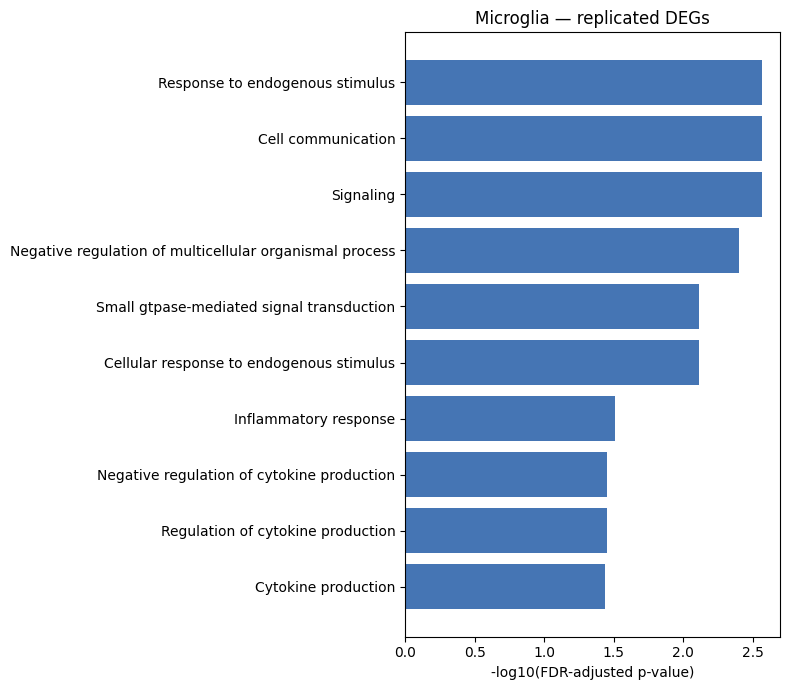

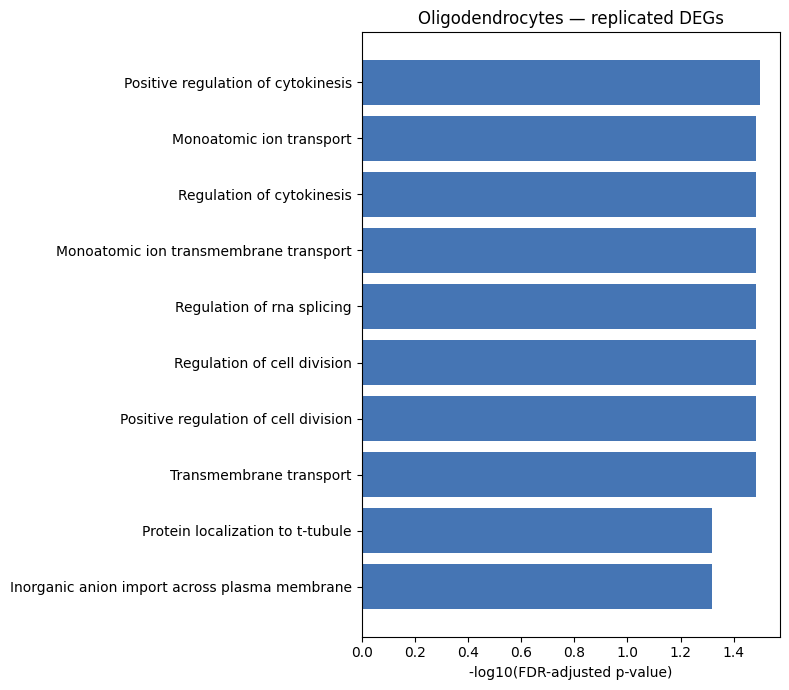

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gprofiler import GProfiler

# =========================================================
# Parameters
# =========================================================
FDR_DISCOVERY = 0.05
MIN_LOG2FC = 0.25
TOP_N = 10

FIG7_DIR = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure7/"
os.makedirs(FIG7_DIR, exist_ok=True)

MIC_KEYWORDS = [
    "inflamm", "cytokine", "interleukin", "immune",
    "microglia", "il-6", "nf-kappa", "chemokine"
]

OLI_KEYWORDS = [
    "neuron", "cell death", "apoptosis", "stress",
    "unfolded", "protein folding", "memory",
    "synaptic", "axon", "degeneration", "myelin",
    "neurite", "dystrophy"
]

# =========================================================
# Load background gene universe
# =========================================================
gene_matrix = pd.read_parquet(
    "/home/adm808/NormalizedCellMatrixSyn18485175.parquet"
)
background_genes = (
    gene_matrix.index.astype(str)
    .str.upper()
    .unique()
    .tolist()
)

gp = GProfiler(return_dataframe=True)

# =========================================================
# Load OLD + NEW DEG files
# =========================================================
dfs_old = {
    "Microglia": pd.read_csv(
        "/n/scratch/users/a/adm808/Contrasts/NPvsCAD/Mathys_Old_Data_DEG_results/poisson_DE_results_Mic.csv"
    ),
    "Oligodendrocytes": pd.read_csv(
        "/n/scratch/users/a/adm808/Contrasts/NPvsCAD/Mathys_Old_Data_DEG_results/poisson_DE_results_Oli.csv"
    ),
}

dfs_new = {
    "Microglia": pd.read_csv(
        "/n/scratch/users/a/adm808/Contrasts/NPvsCAD/Mathys_New_Data_DEG_results/poisson_DE_results_PFC_Mic.csv"
    ),
    "Oligodendrocytes": pd.read_csv(
        "/n/scratch/users/a/adm808/Contrasts/NPvsCAD/Mathys_New_Data_DEG_results/poisson_DE_results_PFC_Oli.csv"
    ),
}

for d in [dfs_old, dfs_new]:
    for k in d:
        d[k].columns = [c.lower() for c in d[k].columns]

# =========================================================
# Direction-consistent DEG definition
# =========================================================
def direction_consistent_genes(df_old, df_new):
    m = df_old.merge(df_new, on="gene", suffixes=("_old", "_new"))

    keep = (
        (m["p_adj_old"] < FDR_DISCOVERY) &
        (m["log2fc_old"].abs() > MIN_LOG2FC) &
        (np.sign(m["log2fc_old"]) == np.sign(m["log2fc_new"]))
    )

    return (
        m.loc[keep, "gene"]
        .astype(str)
        .str.upper()
        .unique()
        .tolist()
    )

mic_genes = direction_consistent_genes(
    dfs_old["Microglia"], dfs_new["Microglia"]
)
oli_genes = direction_consistent_genes(
    dfs_old["Oligodendrocytes"], dfs_new["Oligodendrocytes"]
)

# =========================================================
# Enrichment + plotting logic
# =========================================================
def enrich_and_plot(gene_list, keywords, title, out_png):
    res = gp.profile(
        organism="hsapiens",
        query=gene_list,
        background=background_genes,
        sources=["GO:BP", "REAC", "KEGG"],
        user_threshold=0.05,
        significance_threshold_method="fdr",
        no_evidences=True
    )

    if res.empty:
        print(f"[{title}] No significant pathways.")
        return

    res["name_lower"] = res["name"].str.lower()

    keyword_hits = res[
        (res["p_value"] < 0.05) &
        (res["name_lower"].apply(lambda x: any(k in x for k in keywords)))
    ]

    remaining = res.drop(keyword_hits.index)

    if len(keyword_hits) >= TOP_N:
        final = keyword_hits.nsmallest(TOP_N, "p_value")
    else:
        needed = TOP_N - len(keyword_hits)
        fillers = remaining.nsmallest(needed, "p_value")
        final = pd.concat([keyword_hits, fillers])

    final = final.nsmallest(TOP_N, "p_value").copy()
    final["-log10(p)"] = -np.log10(final["p_value"])
    final["label"] = final["name"].str.capitalize()

    plt.figure(figsize=(8, 4 + 0.3 * len(final)))
    plt.barh(final["label"], final["-log10(p)"], color="#4575b4")
    plt.xlabel("-log10(FDR-adjusted p-value)")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.show()

# =========================================================
# Run + plot
# =========================================================
enrich_and_plot(
    mic_genes,
    MIC_KEYWORDS,
    "Microglia — replicated DEGs",
    f"{FIG7_DIR}/microglia_top10_pathways.png"
)

enrich_and_plot(
    oli_genes,
    OLI_KEYWORDS,
    "Oligodendrocytes — replicated DEGs",
    f"{FIG7_DIR}/oligodendrocytes_top10_pathways.png"
)


Running GSEA for Microglia


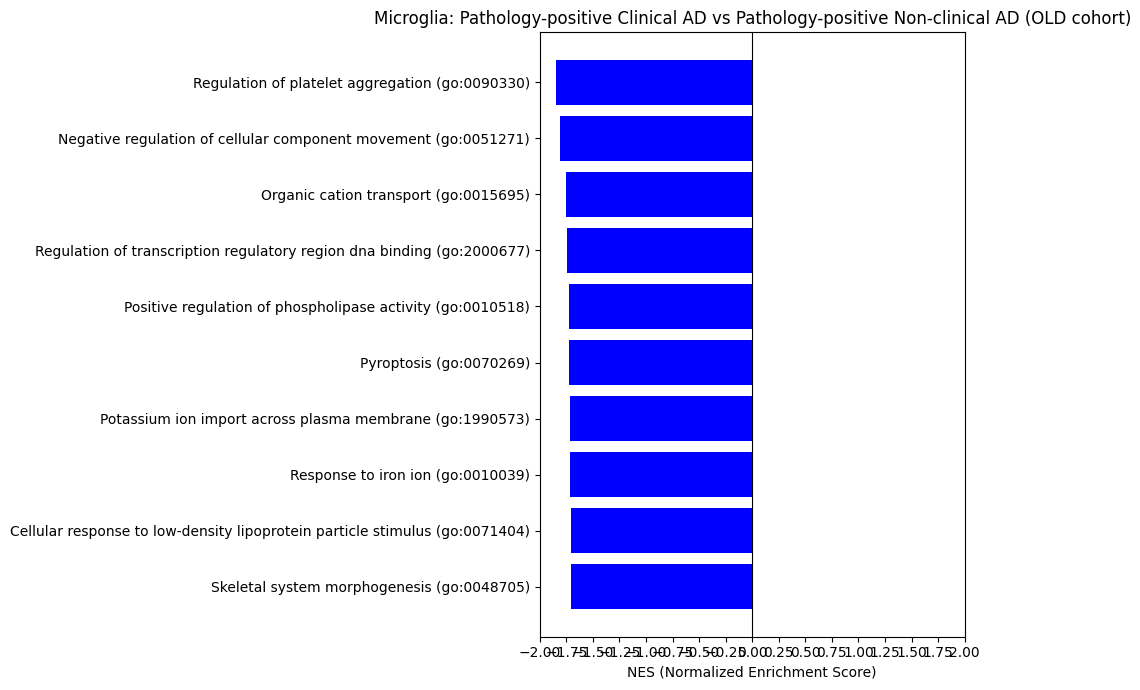

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Contrasts/Revision/Microglia_old_GSEA_top10.png

Running GSEA for Oligodendrocytes


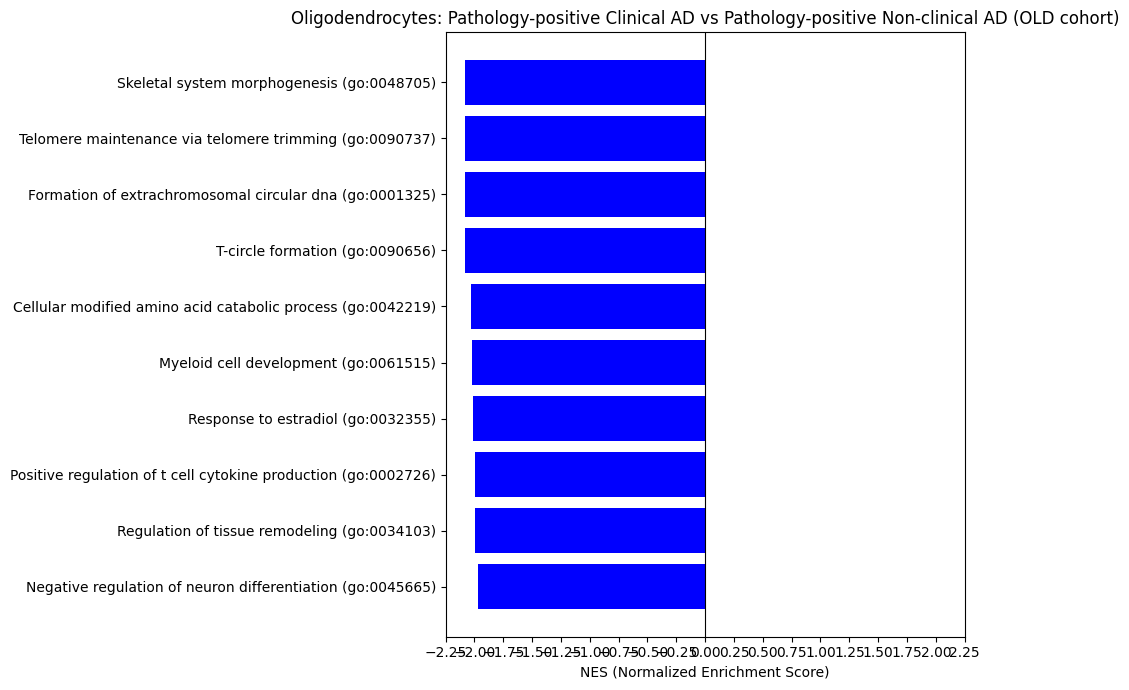

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Contrasts/Revision/Oligodendrocytes_old_GSEA_top10.png


In [1]:
# import pandas as pd
# import gseapy as gp
# import os
# import numpy as np
# import matplotlib.pyplot as plt

# # =========================================================
# # Paths
# # =========================================================
# BASE_DIR = "/n/scratch/users/a/adm808/Contrasts/NPvsCAD/Mathys_Old_Data_DEG_results"
# OUT_DIR  = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Contrasts/Revision"
# os.makedirs(OUT_DIR, exist_ok=True)

# FILES = {
#     "Microglia": f"{BASE_DIR}/poisson_DE_results_Mic.csv",
#     "Oligodendrocytes": f"{BASE_DIR}/poisson_DE_results_Oli.csv",
# }

# # =========================================================
# # GSEA parameters
# # =========================================================
# GENE_SETS = "GO_Biological_Process_2021"
# MIN_SIZE = 10
# MAX_SIZE = 500
# N_PERM   = 1000
# SEED     = 42
# TOP_N    = 10

# # =========================================================
# # Loop over cell types
# # =========================================================
# for cell_type, fpath in FILES.items():

#     print(f"\nRunning GSEA for {cell_type}")

#     # -----------------------------
#     # Load DEG file
#     # -----------------------------
#     df = pd.read_csv(fpath)
#     df.columns = [c.lower() for c in df.columns]

#     if not {"gene", "log2fc"}.issubset(df.columns):
#         raise ValueError(f"{cell_type}: missing gene or log2fc column")

#     # -----------------------------
#     # Build ranked list
#     # -----------------------------
#     ranked = (
#         df[["gene", "log2fc"]]
#         .dropna()
#         .sort_values("log2fc", ascending=False)
#     )

#     rnk_path = os.path.join(OUT_DIR, f"{cell_type}_old_ranked.rnk")
#     ranked.to_csv(rnk_path, sep="\t", index=False, header=False)

#     # -----------------------------
#     # Run preranked GSEA
#     # -----------------------------
#     pre_res = gp.prerank(
#         rnk=rnk_path,
#         gene_sets=GENE_SETS,
#         min_size=MIN_SIZE,
#         max_size=MAX_SIZE,
#         permutation_num=N_PERM,
#         seed=SEED,
#         outdir=None,
#         verbose=False
#     )

#     res = pre_res.res2d.copy()

#     if res.empty:
#         print(f"No enriched pathways for {cell_type}")
#         continue

#     # -----------------------------
#     # Select top pathways by |NES|
#     # -----------------------------
#     top = (
#         res
#         .sort_values("NES", key=lambda x: x.abs(), ascending=False)
#         .head(TOP_N)
#         .copy()
#     )

#     top["Term"] = (
#         top["Term"]
#         .str.replace(r"\s+", " ", regex=True)
#         .str.capitalize()
#     )

#     # -----------------------------
#     # Plot
#     # -----------------------------
#     plt.figure(figsize=(10, 4 + 0.3 * len(top)))
#     plt.barh(
#         top["Term"],
#         top["NES"],
#         color=top["NES"].apply(lambda x: "red" if x > 0 else "blue")
#     )

#     plt.axvline(0, color="black", linewidth=0.8)
#     plt.xlabel("NES (Normalized Enrichment Score)")
#     plt.title(
#         f"{cell_type}: Pathology-positive Clinical AD vs "
#         f"Pathology-positive Non-clinical AD (OLD cohort)"
#     )
#     plt.gca().invert_yaxis()

#     right = np.ceil(abs(top["NES"]).max() / 0.25) * 0.25
#     plt.xlim(-right, right)
#     plt.xticks(np.arange(-right, right + 1e-9, 0.25))

#     out_png = os.path.join(
#         OUT_DIR,
#         f"{cell_type}_old_GSEA_top{TOP_N}.png"
#     )
#     plt.tight_layout()
#     plt.savefig(out_png, dpi=300)
#     plt.show()

#     print(f"Saved: {out_png}")